#Superstore Sales Analysis

In [1]:
#importing pandas
import pandas as pd 

In [2]:
#load dataset
sales=pd.read_csv("Superstore.csv",encoding="latin1")
sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


##Data Understanding & Cleaning

In [4]:
#rows & columns
sales.shape

(9994, 21)

In [5]:
#display column names
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [6]:
#checking info
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
#columns having missing values
Calculting=sales.isna().sum(axis=0)
Calculting[Calculting>0]

Series([], dtype: int64)

In [8]:
#checking duplicates
sales.duplicated().any()

np.False_

In [9]:
#Conver to datetime
sales['Order Date']=pd.to_datetime(sales['Order Date'])
sales['Ship Date']=pd.to_datetime(sales['Ship Date'])

#No nan value and duplicate rows exits

##Filtering & Sorting

In [11]:
#unique customers
sales['Customer ID'].nunique()

793

In [12]:
#unique products sold
sales['Product ID'].nunique()

1862

In [14]:
#states with highest number of orders
sales['State'].value_counts().head(1)


State
California    2001
Name: count, dtype: int64

In [15]:
#sales greater than 1000
sales[sales['Sales']>1000]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184,9,0.2,85.3092
24,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.630,3,0.0,240.2649
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7,0.5,-1665.0522
35,36,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,TEC-PH-10004977,Technology,Phones,GE 30524EE4,1097.544,7,0.2,123.4737
54,55,CA-2016-105816,2016-12-11,2016-12-17,Standard Class,JM-15265,Janet Molinari,Corporate,United States,New York City,...,10024,East,TEC-PH-10002447,Technology,Phones,AT&T CL83451 4-Handset Telephone,1029.950,5,0.0,298.6855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,9867,US-2015-116981,2015-03-26,2015-03-28,Second Class,SM-20950,Suzanne McNair,Corporate,United States,New York City,...,10009,East,OFF-ST-10002615,Office Supplies,Storage,"Dual Level, Single-Width Filing Carts",1085.420,7,0.0,282.2092
9925,9926,CA-2015-159534,2015-03-20,2015-03-23,First Class,DH-13075,Dave Hallsten,Corporate,United States,New York City,...,10035,East,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,1087.936,8,0.2,353.5792
9929,9930,CA-2016-129630,2016-09-04,2016-09-04,Same Day,IM-15055,Ionia McGrath,Consumer,United States,San Francisco,...,94122,West,TEC-CO-10003763,Technology,Copiers,Canon PC1060 Personal Laser Copier,2799.960,5,0.2,944.9865
9947,9948,CA-2017-121559,2017-06-01,2017-06-03,Second Class,HW-14935,Helen Wasserman,Corporate,United States,Indianapolis,...,46203,Central,FUR-CH-10003746,Furniture,Chairs,Hon 4070 Series Pagoda Round Back Stacking Chairs,1925.880,6,0.0,539.2464


In [16]:
# products causing loss
products=sales .groupby('Product Name')['Profit'].sum()
products[products<0]


Product Name
3.6 Cubic Foot Counter Height Office Refrigerator                 -872.0752
36X48 HARDFLOOR CHAIRMAT                                           -40.4914
3D Systems Cube Printer, 2nd Generation, White                    -467.9964
3M Replacement Filter for Office Air Cleaner for 20' x 33' Room    -20.4768
ARKON Windshield Dashboard Air Vent Car Mount Holder               -15.5940
                                                                     ...   
XtraLife ClearVue Slant-D Ring Binders by Cardinal                 -13.3280
Zebra GK420t Direct Thermal/Thermal Transfer Printer              -938.2800
i.Sound Portable Power - 8000 mAh                                  -58.8189
iOttie HLCRIO102 Car Mount                                         -11.9940
iOttie XL Car Mount                                                -50.3748
Name: Profit, Length: 301, dtype: float64

In [17]:
#orders of technology category
sales[sales['Category']=='Technology']

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
11,12,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.424,4,0.2,68.3568
19,20,CA-2014-143336,2014-08-27,2014-09-01,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,...,94109,West,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480,3,0.2,16.0110
26,27,CA-2016-121755,2016-01-16,2016-01-20,Second Class,EH-13945,Eric Hoffmann,Consumer,United States,Los Angeles,...,90049,West,TEC-AC-10003027,Technology,Accessories,Imation 8GB Mini TravelDrive USB 2.0 Flash Drive,90.570,3,0.0,11.7741
35,36,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,TEC-PH-10004977,Technology,Phones,GE 30524EE4,1097.544,7,0.2,123.4737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9983,9984,US-2016-157728,2016-09-22,2016-09-28,Standard Class,RC-19960,Ryan Crowe,Consumer,United States,Grand Rapids,...,49505,Central,TEC-PH-10001305,Technology,Phones,Panasonic KX TS208W Corded phone,97.980,2,0.0,27.4344
9986,9987,CA-2016-125794,2016-09-29,2016-10-03,Standard Class,ML-17410,Maris LaWare,Consumer,United States,Los Angeles,...,90008,West,TEC-AC-10003399,Technology,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,0.0,15.2208
9987,9988,CA-2017-163629,2017-11-17,2017-11-21,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-AC-10001539,Technology,Accessories,Logitech G430 Surround Sound Gaming Headset wi...,79.990,1,0.0,28.7964
9988,9989,CA-2017-163629,2017-11-17,2017-11-21,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-PH-10004006,Technology,Phones,Panasonic KX - TS880B Telephone,206.100,5,0.0,55.6470


In [18]:
#From California
sales[sales['State']=='California']

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9986,9987,CA-2016-125794,2016-09-29,2016-10-03,Standard Class,ML-17410,Maris LaWare,Consumer,United States,Los Angeles,...,90008,West,TEC-AC-10003399,Technology,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,0.0,15.2208
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200


In [19]:
#10 highest sales orders
sales.sort_values(by='Sales',ascending=False).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,4278,US-2016-107440,2016-04-16,2016-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6425,6426,CA-2016-143714,2016-05-23,2016-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [20]:
#10 lowest profit orders
sales.sort_values('Profit').head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7772,7773,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,684,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,3012,CA-2017-134845,2017-04-17,2017-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,80027,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,4992,US-2017-122714,2017-12-07,2017-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,60653,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,3152,CA-2015-147830,2015-12-15,2015-12-18,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,...,43055,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,5311,CA-2017-131254,2017-11-19,2017-11-21,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,77095,Central,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,9640,CA-2015-116638,2015-01-28,2015-01-31,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,1200,CA-2016-130946,2016-04-08,2016-04-12,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,77041,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784


##Analysis

In [21]:
#highest total sales
sales.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(1)

Category
Technology    836154.033
Name: Sales, dtype: float64

In [22]:
#highest total profit
sales.groupby('Category')['Profit'].sum().sort_values(ascending=False).head(1)

Category
Technology    145454.9481
Name: Profit, dtype: float64

In [23]:
#least total profit
sales.groupby('Sub-Category')['Profit'].sum().sort_values().head(1)

Sub-Category
Tables   -17725.4811
Name: Profit, dtype: float64

In [24]:
#spent most money
sales.groupby(['Customer ID','Customer Name'])['Sales'].sum().sort_values(ascending=False).head(1)

Customer ID  Customer Name
SM-20320     Sean Miller      25043.05
Name: Sales, dtype: float64

In [25]:
#most profit
sales.groupby(['Customer ID','Customer Name'])['Profit'].sum().sort_values(ascending=False).head(1)

Customer ID  Customer Name
TC-20980     Tamara Chand     8981.3239
Name: Profit, dtype: float64

In [26]:
#city highest sales
sales.groupby('City')['Sales'].sum().sort_values(ascending=False).head(1)

City
New York City    256368.161
Name: Sales, dtype: float64

In [27]:
#region highest profit
sales.groupby('Region')['Profit'].sum().sort_values(ascending=False).head(1)

Region
West    108418.4489
Name: Profit, dtype: float64

In [27]:
#highest quantity
sales.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(1)

Product Name
Staples    215
Name: Quantity, dtype: int64

##Ranking

In [28]:
#rank products within each category
psales=sales.groupby(['Category','Product Name'])['Sales'].sum()
psales.groupby(level=0).rank(method='dense',ascending=False)



Category    Product Name                                                                                       
Furniture   12-1/2 Diameter Round Wall Clock                                                                       226.0
            24-Hour Round Wall Clock                                                                               237.0
            36X48 HARDFLOOR CHAIRMAT                                                                               257.0
            3M Hangers With Command Adhesive                                                                       341.0
            3M Polarizing Light Filter Sleeves                                                                     286.0
                                                                                                                   ...  
Technology  iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4    270.0
            iOttie HLCRIO102 Car Mount   

In [29]:
#rank customers
sales.groupby('Customer ID')['Sales'].sum().rank(ascending=False)

Customer ID
AA-10315     92.0
AA-10375    612.0
AA-10480    471.0
AA-10645    115.0
AB-10015    652.0
            ...  
XP-21865    375.0
YC-21895     99.0
YS-21880     60.0
ZC-21910     38.0
ZD-21925    520.0
Name: Sales, Length: 793, dtype: float64

In [30]:
#rank states
sales.groupby('State')['Profit'].sum().rank(ascending=False)


State
Alabama                 17.0
Arizona                 42.0
Arkansas                19.0
California               1.0
Colorado                44.0
Connecticut             20.0
Delaware                10.0
District of Columbia    32.0
Florida                 41.0
Georgia                  7.0
Idaho                   34.0
Illinois                46.0
Indiana                  6.0
Iowa                    30.0
Kansas                  33.0
Kentucky                 8.0
Louisiana               25.0
Maine                   35.0
Maryland                14.0
Massachusetts           15.0
Michigan                 4.0
Minnesota                9.0
Mississippi             22.0
Missouri                16.0
Montana                 27.0
Nebraska                26.0
Nevada                  21.0
New Hampshire           29.0
New Jersey              11.0
New Mexico              31.0
New York                 2.0
North Carolina          45.0
North Dakota            37.0
Ohio                    48.0
Oklahoma

##Pivot Table Analysis

In [31]:
#sales camparsion by category and Region
pd.pivot_table(sales,values='Sales',index='Category',columns='Region',aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


In [58]:
#profit camparsion by category and segment
pd.pivot_table(sales,values='Sales',index='Category',columns='Segment',aggfunc='sum')

Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,391049.312,229019.7858,121930.6975
Office Supplies,363952.136,230676.4620,124418.4340
Technology,406399.897,246450.1190,183304.0170


In [32]:
#quantity sold by category and region
pd.pivot_table(sales,values='Quantity',index='Category',columns='Region',aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,1827,2214,1291,2696
Office Supplies,5409,6462,3800,7235
Technology,1544,1942,1118,2335


##Date Analysis

In [33]:
#month with highest sale
sales['Month']=sales['Order Date'].dt.month_name()
sales.groupby('Month')['Sales'].sum().idxmax()

'November'

In [34]:
#month with highest profit
sales.groupby('Month')['Profit'].sum().idxmax()

'December'

In [35]:
#month with highest number of orders
sales.groupby('Month')['Order ID'].count().idxmax()

'November'

##Business Questions

In [36]:
#products causing losses
sales.groupby('Product Name')['Profit'].sum().idxmin()

'Cubify CubeX 3D Printer Double Head Print'

In [37]:
#customer with most orders
sales.groupby(['Customer ID','Customer Name'])['Order ID'].count().idxmax()

('WB-21850', 'William Brown')

In [38]:
#category with highest average order value
sales.groupby('Category')['Sales'].mean().idxmax()

'Technology'

In [39]:
#state with highest profit
sales.groupby('State')['Profit'].sum().idxmax()

'California'

##Visulization(using Pandas.plot())

<Axes: title={'center': 'Total Sales by Category'}, xlabel='Category', ylabel='Sales'>

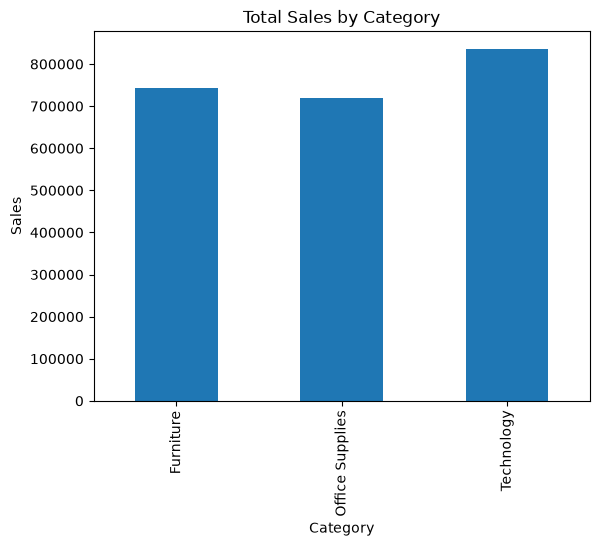

In [40]:
#bar chart of sales by category
category_sales=sales.groupby('Category')['Sales'].sum()
category_sales.plot(
    kind='bar',
    title='Total Sales by Category',
    xlabel='Category',
    ylabel='Sales'
)


Technology generated the highest total sales.

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month'>

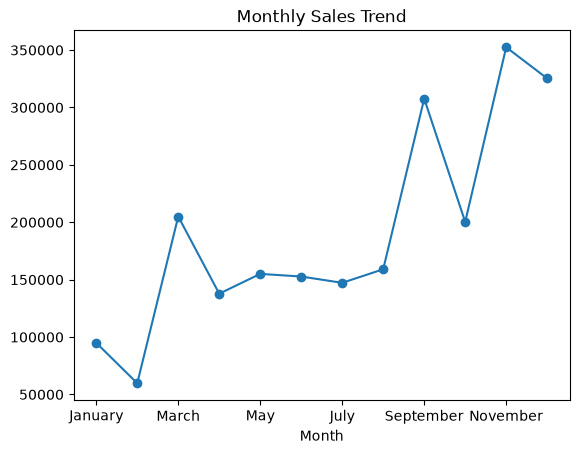

In [41]:
#monthly sales trend
sales['Month Number']=sales['Order Date'].dt.month
monthly_sales=sales.groupby(['Month Number','Month'])['Sales'].sum()
monthly_sales=monthly_sales.sort_index(level=0)
monthly_sales.reset_index(level=0,drop=True).plot(
    kind='line',
    marker='o',
    title='Monthly Sales Trend'
)

Sales peaked in November.

<Axes: title={'center': 'Sales Distribution'}, xlabel='Sales', ylabel='Number of Orders'>

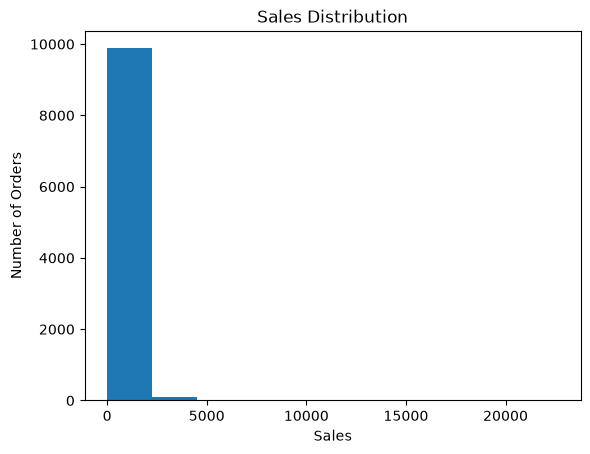

In [4]:
#sales distribution
sales['Sales'].plot(
    kind='hist',
    title='Sales Distribution',
    xlabel='Sales',
    ylabel='Number of Orders'
)


Most orders have relatively low sales, with a few high-value orders.

<Axes: title={'center': 'Sales Proportion by Category'}>

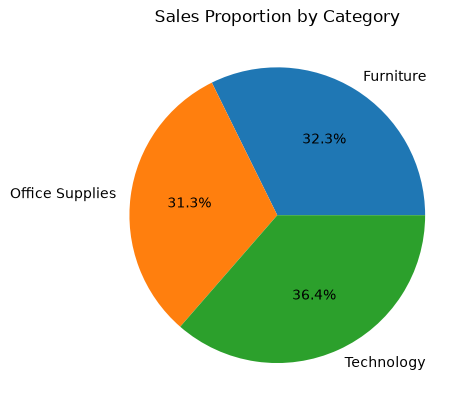

In [43]:
#sales proportion by category
sales_proportion=sales.groupby('Category')['Sales'].sum()
sales_proportion.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Sales Proportion by Category' 
)


Technology contributes the largest share of total sales

##Final Report

In [44]:
#total sales
sales['Sales'].sum()

np.float64(2297200.8603)

In [45]:
#total profit
sales['Profit'].sum()

np.float64(286397.0217)

In [46]:
#most valuable customer
sales.groupby(['Customer ID','Customer Name'])['Sales'].sum().idxmax()


('SM-20320', 'Sean Miller')

##Business Insights
1. Technology category generated the highest total sales.
2. Multiple products generated negative profit, indicating areas that need improvement.
3. William Brown placed the highest number of orders.
4. Sean Miller generated highest sales.
5. November recorded the highest sales.
6. California generated the highest total profit.

##Conclusion

  The Superstore Sales analysis helped identify the best-performing categories, profitable regions, valuable customers, and products causing losses. These findings provide a clear understanding of the company's sales and profit performance.

##Recommendations

* Focus more on high-performing categories and  profitable states.
* Review pricing, discounts, or costs for loss-making products.
* Build stronger relationships with high-value customers.
* Analyze successful sales strategies from the best-performing month and apply them in lower-performing period.